## Feature-based ML: Random Forest

## Information ##

This notebook walks through the indoor (or outdoor) electrode importance analysis so you can run each step independently.

**IMPORTANT:** Before running this notebook, please update the `DATA_DIRECTORY` variable in Section 4 to point to your processed data folder.

**Expected folder structure:**
```
your_data_folder/
├── sub-P001/
│   ├── indoor_processed-epo.fif
│   └── outdoor_processed-epo.fif
├── sub-P002/
│   ├── indoor_processed-epo.fif
│   └── outdoor_processed-epo.fif
└── ...
```

## 1) Initialize Environment and Dependencies

The seed was fixed after the second run to ensure reproducibility and make the analysis more comprehensive.

In [135]:
# Optional: install requirements into the current kernel

# Remove the leading '!' if you prefer running in a terminal instead of the notebook

# !pip install -r ../requirements.txt



import sys, os, random

import numpy as np

import pandas as pd



# Reproducibility

RANDOM_SEED = 42

random.seed(RANDOM_SEED)

np.random.seed(RANDOM_SEED)



print("Python:", sys.version)

print("Working dir:", os.getcwd())

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Working dir: c:\Users\morit\Downloads


## 2) Import Libraries and Project Modules

Importing essential packages for analysis and plotting below.


In [136]:
import mne

import matplotlib.pyplot as plt

import seaborn as sns

from pathlib import Path

from collections import defaultdict



from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_score

from sklearn.preprocessing import StandardScaler

from sklearn.feature_selection import SelectKBest, f_classif



sns.set_context("talk")

plt.rcParams["figure.facecolor"] = "white"

print("MNE:", mne.__version__)

MNE: 1.10.1


## 3) Define Runtime Parameters and Data Paths

Configure the analysis session, electrode settings, and specify where your processed data files are located.

In [137]:
# =============================================================================
# DATA DIRECTORY CONFIGURATION
# =============================================================================
# IMPORTANT: Update this path to point to your processed data directory
# The directory should contain subdirectories for each participant with epo.fif files

DATA_DIRECTORY = "./results"  # <-- CHANGE THIS PATH IF NEEDED

# =============================================================================
# ANALYSIS PARAMETERS
# =============================================================================
ANALYSIS_SESSION = "indoor" # Do not change this here!
INCLUDE_0_BACK = False  # Do not change this here!
ALL_ELECTRODES = ["Fz", "C4", "Cz", "C3", "Pz", "PO8", "Oz", "PO7"]

# Results output directory
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# Validate data directory
data_dir_path = Path(DATA_DIRECTORY)
if not data_dir_path.exists():
    print(f"WARNING: Data directory '{DATA_DIRECTORY}' does not exist!")
    print("Please update the DATA_DIRECTORY variable above to point to your processed data folder.")
    print("Expected structure: {DATA_DIRECTORY}/sub-P001/indoor_processed-epo.fif, etc.")
else:
    print(f"Data directory found: {data_dir_path.absolute()}")
    # List available participants
    participant_dirs = [p.name for p in data_dir_path.iterdir() if p.is_dir() and p.name.startswith('sub-')]
    print(f"Found {len(participant_dirs)} participant directories: {participant_dirs[:3]}{'...' if len(participant_dirs) > 3 else ''}")

print("\nAnalysis Configuration:")
print(f"  Session: {ANALYSIS_SESSION}")
print(f"  Include 0-back: {INCLUDE_0_BACK}")
print(f"  Data directory: {DATA_DIRECTORY}")
print(f"  Results directory: {RESULTS_DIR}")

Data directory found: C:\Users\morit\OneDrive\Desktop\Uni\Master Neuroscience\Semester 2\BPR\BPR Git\eeg-brain-interface\Abgabe\results
Found 0 participant directories: []

Analysis Configuration:
  Session: indoor
  Include 0-back: False
  Data directory: C:\Users\morit\OneDrive\Desktop\Uni\Master Neuroscience\Semester 2\BPR\BPR Git\eeg-brain-interface\Abgabe\results
  Results directory: results


## 4) Discover Participants and Load Data

Participants data is only used when the processed data is existing and contains both the indoor and outdoor session. When this is not the case the participant is skipped.

In [138]:
from typing import List, Tuple, Dict, Optional

def get_available_participants() -> List[str]:
    """Get list of available participants from the configured data directory."""
    processed_dir = Path(DATA_DIRECTORY)
    if not processed_dir.exists():
        print(f"Data directory not found: {processed_dir}")
        return []
    parts = [p.name for p in processed_dir.iterdir() if p.is_dir() and not p.name.endswith('.csv')]
    return sorted(parts)

def load_participant_session(participant: str, session_type: str):
    """Load participant session data from the configured data directory."""
    epo_file = Path(DATA_DIRECTORY) / participant / f"{session_type}_processed-epo.fif"
    if not epo_file.exists():
        print(f"Missing file for {participant} {session_type}: {epo_file}")
        return None
    try:
        epochs = mne.read_epochs(epo_file, preload=True, verbose=False)
        if INCLUDE_0_BACK:
            analysis_events = ['0-back', '1-back', '2-back', '3-back']
            event_id_to_difficulty = {epochs.event_id['0-back']: 0,
                                      epochs.event_id['1-back']: 1,
                                      epochs.event_id['2-back']: 2,
                                      epochs.event_id['3-back']: 3}
        else:
            analysis_events = ['1-back', '2-back', '3-back']
            event_id_to_difficulty = {epochs.event_id['1-back']: 1,
                                      epochs.event_id['2-back']: 2,
                                      epochs.event_id['3-back']: 3}
        ep = epochs[analysis_events]
        if len(ep) < 10:
            print(f"Too few epochs for {participant} {session_type}: {len(ep)}")
            return None
        difficulties = [event_id_to_difficulty[eid] for eid in ep.events[:, 2]]
        meta = pd.DataFrame({
            'difficulty': difficulties,
            'participant': [participant]*len(ep),
            'session_type': [session_type]*len(ep),
        })
        ep.metadata = meta
        print(f"Loaded {participant} {session_type}: {len(ep)} epochs")
        return ep
    except Exception as e:
        print(f"Error loading {participant} {session_type}: {e}")
        return None

def extract_features(epochs_data, exclude_channels: Optional[List[str]] = None) -> Tuple[np.ndarray, List[str], object]:
    bands = {"theta": (4, 8), "alpha": (8, 13), "beta": (13, 30), "gamma": (30, 40)}
    ep_filt = epochs_data.copy().filter(4.0, 40.0, picks="eeg")
    if exclude_channels:
        to_drop = [ch for ch in exclude_channels if ch in ep_filt.ch_names]
        if to_drop:
            ep_filt.drop_channels(to_drop)
    try:
        psd = ep_filt.compute_psd(method="welch", fmin=1.0, fmax=40.0,
                                  n_fft=int(ep_filt.info["sfreq"]*2),
                                  n_overlap=int(ep_filt.info["sfreq"]*1),
                                  picks="eeg", verbose=False)
        psds, freqs = psd.get_data(return_freqs=True)
    except Exception:
        from mne.time_frequency import psd_welch
        psds, freqs = psd_welch(ep_filt, fmin=1.0, fmax=40.0,
                                n_fft=int(ep_filt.info["sfreq"]*2),
                                n_overlap=int(ep_filt.info["sfreq"]*1),
                                picks="eeg", average="mean", verbose=False)
    bin_mask = {b: (freqs >= lo) & (freqs < hi) for b,(lo,hi) in bands.items()}
    total_pow = psds.sum(axis=2) + 1e-12
    feat_list, col_names = [], []
    for b, m in bin_mask.items():
        bp = psds[:, :, m].sum(axis=2)
        rel = bp / total_pow
        feat_list.append(rel)
        col_names += [f"{ch}_{b}" for ch in ep_filt.ch_names]
    X = np.concatenate(feat_list, axis=1)
    return X, col_names, ep_filt

def train_and_evaluate_rf(X: np.ndarray, y: np.ndarray, cv_folds: int = 5):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    if X_scaled.shape[1] > 20:
        selector = SelectKBest(score_func=f_classif, k=20)
        X_selected = selector.fit_transform(X_scaled, y)
    else:
        X_selected = X_scaled
    min_class = np.bincount(y).min()
    n_splits = min(cv_folds, int(min_class)) if min_class > 1 else 2
    rf = RandomForestClassifier(n_estimators=1000, min_samples_split=4, min_samples_leaf=6,
                               class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    scores = cross_val_score(rf, X_selected, y, cv=cv, scoring="accuracy", n_jobs=-1)
    return scores.mean(), scores.std(), scores

def analyze_single_participant_session(participant: str, session_type: str):
    epochs = load_participant_session(participant, session_type)
    if epochs is None:
        return None
    y = epochs.metadata["difficulty"].astype(int).to_numpy()
    results = []
    print("→ Baseline (all electrodes)...")
    X_all, _, _ = extract_features(epochs)
    base_mean, base_std, _ = train_and_evaluate_rf(X_all, y)
    results.append({
        'participant': participant,
        'session_type': session_type,
        'condition': 'baseline',
        'excluded_electrode': 'None',
        'accuracy_mean': base_mean,
        'accuracy_std': base_std,
        'accuracy_drop': 0.0,
    })
    print(f"  Baseline: {base_mean:.3f} ± {base_std:.3f}")
    # Leave-one-out
    print("→ Leave-one-out electrode analysis...")
    for el in ALL_ELECTRODES:
        X_excl, _, _ = extract_features(epochs, exclude_channels=[el])
        if X_excl.size == 0:
            continue
        acc_mean, acc_std, _ = train_and_evaluate_rf(X_excl, y)
        drop = base_mean - acc_mean
        results.append({
            'participant': participant,
            'session_type': session_type,
            'condition': 'leave_one_out',
            'excluded_electrode': el,
            'accuracy_mean': acc_mean,
            'accuracy_std': acc_std,
            'accuracy_drop': drop,
        })
        print(f"  {el}: drop = {drop:.3f}")
    return results

## 5) Execute Analysis for Selected Session

In [139]:
participants = get_available_participants()
print(f"Found {len(participants)} participants:", participants)

SESSION_TYPES = [ANALYSIS_SESSION]

ALL_RESULTS = []
ELECTRODE_RANKINGS = defaultdict(list)
ELECTRODE_RANK_SUMS = defaultdict(int)

for participant in participants:
    for session_type in SESSION_TYPES:
        res = analyze_single_participant_session(participant, session_type)
        if res:
            ALL_RESULTS.extend(res)
            
            # Calculate individual participant ranking
            participant_results = pd.DataFrame(res)
            loo_participant = participant_results[participant_results['condition'] == 'leave_one_out']
            if not loo_participant.empty:
                drops_participant = (loo_participant.groupby('excluded_electrode')['accuracy_drop']
                                   .mean()
                                   .sort_values(ascending=False))
                rank_order_participant = list(drops_participant.index)
                print(f"  {participant} rank order: {rank_order_participant}")
                
                # Add individual ranks to summing
                for idx, el in enumerate(rank_order_participant, 1):
                    ELECTRODE_RANKINGS[el].append(idx)
                    ELECTRODE_RANK_SUMS[el] += idx

import pandas as pd
if not ALL_RESULTS:
    print("No analyses completed successfully!")
else:
    all_results_df = pd.DataFrame(ALL_RESULTS)
    print(all_results_df.head())
    
    # Also calculate overall ranking for comparison
    loo = all_results_df[all_results_df['condition']== 'leave_one_out']
    drops_by_el = (loo.groupby('excluded_electrode')['accuracy_drop']
                     .mean()
                     .sort_values(ascending=False))
    overall_rank_order = list(drops_by_el.index)
    print("Overall rank order (all participants combined):", overall_rank_order)
    print("Individual rank sums:", dict(ELECTRODE_RANK_SUMS))

Found 14 participants: ['Abdullah', 'Aliaa', 'Anita', 'Jassim', 'Jonas', 'Julian', 'Julius', 'Lotta', 'Moritz', 'Nils', 'Rami', 'cihan', 'jannik', 'julia']
Missing file for Abdullah indoor: C:\Users\morit\OneDrive\Desktop\Uni\Master Neuroscience\Semester 2\BPR\BPR Git\eeg-brain-interface\Abgabe\results\Abdullah\indoor_processed-epo.fif
Adding metadata with 3 columns
Loaded Aliaa indoor: 600 epochs
→ Baseline (all electrodes)...
Loaded Aliaa indoor: 600 epochs
→ Baseline (all electrodes)...
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 sample

## 6) Visualize Results

Saved: results\indoor_electrode_analysis_visualization.png


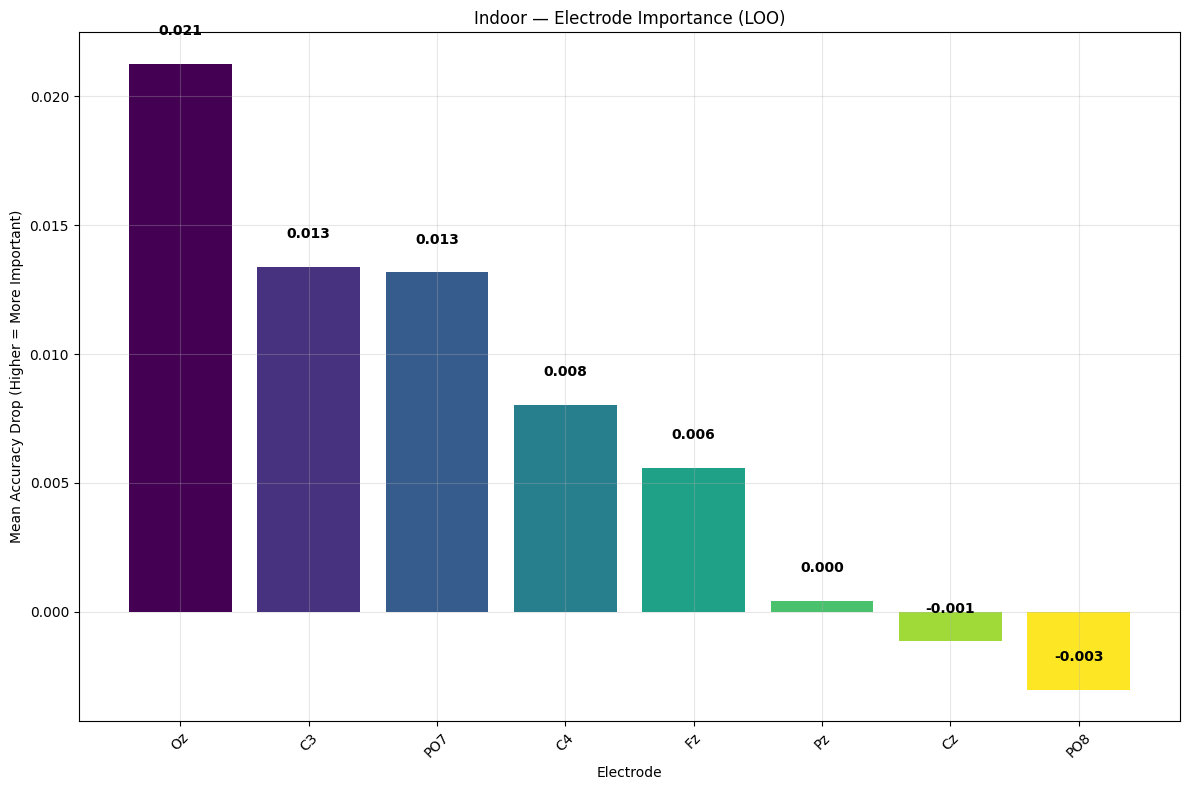

Saved: results\indoor_electrode_rank_sum_visualization.png


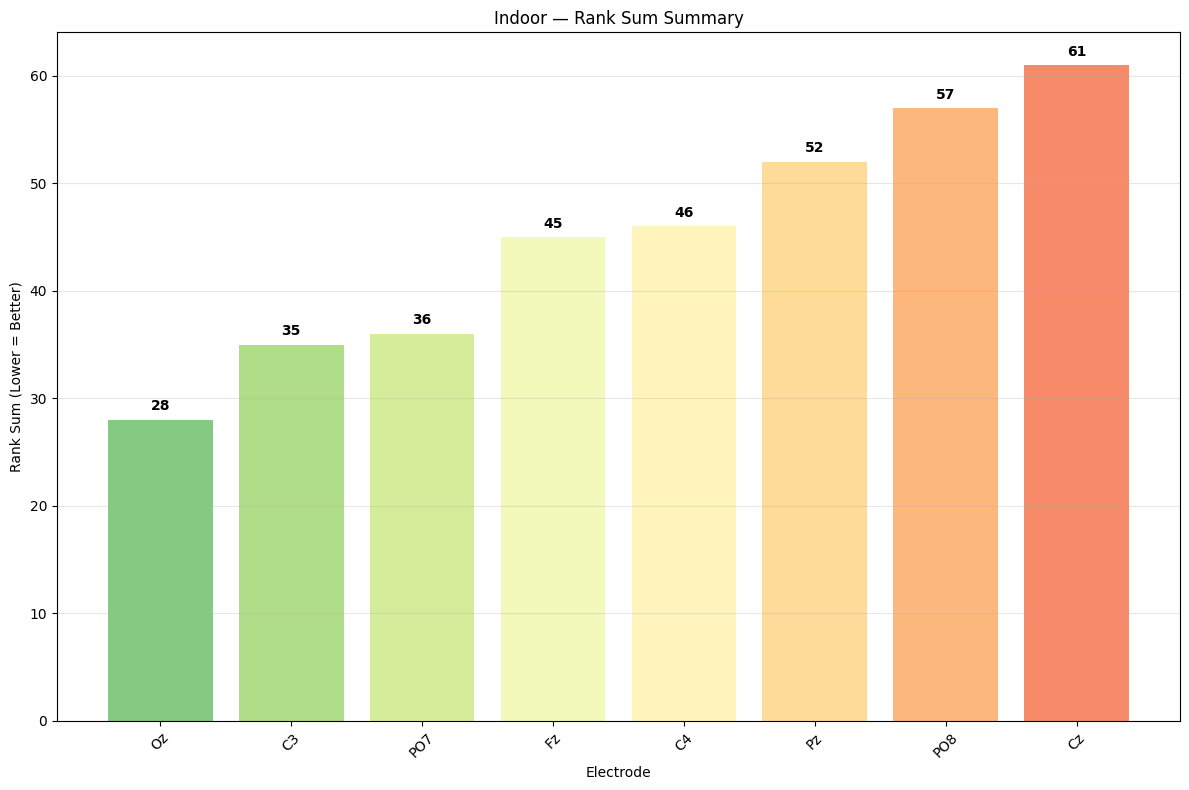

In [140]:
def create_session_visualization(all_results_df: pd.DataFrame, session_type: str = "indoor"):
    if all_results_df is None or all_results_df.empty:
        print(f"No {session_type} analysis results to visualize!")
        return None
    plt.style.use('default')
    sns.set_palette("Set2")
    fig, ax = plt.subplots(figsize=(12, 8))
    loo = all_results_df[all_results_df['condition']=='leave_one_out'].copy()
    if loo.empty:
        ax.text(0.5, 0.5, f'No leave-one-out data for {session_type}', ha='center', va='center', transform=ax.transAxes)
        return fig
    drops = (loo.groupby('excluded_electrode')['accuracy_drop']
               .mean()
               .sort_values(ascending=False))
    bars = ax.bar(range(len(drops)), drops.values, color=plt.cm.viridis(np.linspace(0,1,len(drops))))
    ax.set_xlabel('Electrode')
    ax.set_ylabel('Mean Accuracy Drop (Higher = More Important)')
    ax.set_title(f'{session_type.title()} — Electrode Importance (LOO)')
    ax.set_xticks(range(len(drops)))
    ax.set_xticklabels(drops.index, rotation=45)
    ax.grid(True, alpha=0.3)
    for i, (el, val) in enumerate(drops.items()):
        ax.text(i, val + 0.001, f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    out = RESULTS_DIR / f"{session_type}_electrode_analysis_visualization.png"
    plt.savefig(out, dpi=300, bbox_inches='tight')
    print("Saved:", out)
    plt.show()
    return out

def create_rank_sum_visualization(rank_sum_data: Dict[str,int], session_type: str = "indoor"):
    if not rank_sum_data:
        print(f"No rank sum data to visualize for {session_type}!")
        return None
    items = sorted(rank_sum_data.items(), key=lambda x: x[1])
    fig, ax = plt.subplots(figsize=(12,8))
    labels = [k for k,_ in items]
    vals = [v for _,v in items]
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(labels)))
    ax.bar(range(len(labels)), vals, color=colors, alpha=0.8)
    ax.set_xlabel('Electrode')
    ax.set_ylabel('Rank Sum (Lower = Better)')
    ax.set_title(f'{session_type.title()} — Rank Sum Summary')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    for i,(lab,val) in enumerate(zip(labels, vals)):
        ax.text(i, val + max(vals)*0.01, f'{val}', ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    out = RESULTS_DIR / f"{session_type}_electrode_rank_sum_visualization.png"
    plt.savefig(out, dpi=300, bbox_inches='tight')
    print("Saved:", out)
    plt.show()
    return out

# If we have results, render plots
if 'all_results_df' in globals():
    _ = create_session_visualization(all_results_df, ANALYSIS_SESSION)
    _ = create_rank_sum_visualization(ELECTRODE_RANK_SUMS, ANALYSIS_SESSION)

## 7) Save CSV Outputs

In [141]:
if 'all_results_df' in globals():

    session_name = ANALYSIS_SESSION

    detailed_path = RESULTS_DIR / f"electrode_analysis_{session_name}_only.csv"

    all_results_df.to_csv(detailed_path, index=False)

    print("Saved:", detailed_path)



    # Ranking summary and rank sums

    if ELECTRODE_RANK_SUMS:

        # Average ranking based on ELECTRODE_RANKINGS

        from statistics import mean, pstdev

        avg_rankings = {}

        for el, ranks in ELECTRODE_RANKINGS.items():

            if ranks:

                avg_rankings[el] = (mean(ranks), pstdev(ranks) if len(ranks) > 1 else 0.0)

        ranking_summary = pd.DataFrame([

            {'electrode': el, 'avg_rank': avg, 'std_rank': std, 'consistency_score': (1/std) if std > 0 else float('inf')}

            for el, (avg, std) in avg_rankings.items()

        ]).sort_values('avg_rank')

        ranking_path = RESULTS_DIR / f"electrode_ranking_{session_name}_only.csv"

        ranking_summary.to_csv(ranking_path, index=False)

        print("Saved:", ranking_path)



        rank_sum_summary = pd.DataFrame([

            {'electrode': el, 'rank_sum': s, 'avg_rank': s / max(1, len(ELECTRODE_RANKINGS.get(el, [])))}

            for el, s in ELECTRODE_RANK_SUMS.items()

        ]).sort_values('avg_rank')

        rank_sum_path = RESULTS_DIR / f"electrode_rank_sums_{session_name}_only.csv"

        rank_sum_summary.to_csv(rank_sum_path, index=False)

        print("Saved:", rank_sum_path)

Saved: results\electrode_analysis_indoor_only.csv
Saved: results\electrode_ranking_indoor_only.csv
Saved: results\electrode_rank_sums_indoor_only.csv


## 8) Enhanced 8 vs 4 Analysis (Indoor Training → Outdoor Generalization)

This section compares 8 electrodes vs the best 4 (by ranking) using indoor data for training and cross-validation, tests statistical significance with a paired t-test on CV folds, and evaluates how well the models generalize to outdoor data. This is specifically designed to test indoor→outdoor generalization.

**Note:** This section always trains on indoor data regardless of the ANALYSIS_SESSION parameter, as it's designed to test generalization from indoor to outdoor conditions.

In [142]:
from sklearn.base import clone

from sklearn.model_selection import StratifiedKFold

from scipy import stats



def train_and_evaluate_rf_with_models(X, y, cv_folds=5):

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    selector = None

    if X_scaled.shape[1] > 20:

        selector = SelectKBest(score_func=f_classif, k=20)

        X_selected = selector.fit_transform(X_scaled, y)

    else:

        X_selected = X_scaled

    min_class = np.bincount(y).min()

    n_splits = min(cv_folds, int(min_class)) if min_class > 1 else 2

    rf = RandomForestClassifier(n_estimators=1000, min_samples_split=4, min_samples_leaf=6,

                               class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)

    fold_scores = []

    trained_models = []

    for train_idx, val_idx in cv.split(X_selected, y):

        X_train, X_val = X_selected[train_idx], X_selected[val_idx]

        y_train, y_val = y[train_idx], y[val_idx]

        model = clone(rf)

        model.fit(X_train, y_train)

        fold_scores.append(model.score(X_val, y_val))

        trained_models.append({'model': model, 'scaler': scaler, 'selector': selector})

    return np.mean(fold_scores), np.std(fold_scores), np.array(fold_scores), trained_models



def test_models_on_outdoor_data(trained_models, outdoor_epochs, exclude_channels=None):

    if outdoor_epochs is None:

        return None, None, None

    y_outdoor = outdoor_epochs.metadata["difficulty"].astype(int).to_numpy()

    X_outdoor, _, _ = extract_features(outdoor_epochs, exclude_channels=exclude_channels)

    scores = []

    for info in trained_models:

        Xs = info['scaler'].transform(X_outdoor)

        Xsel = info['selector'].transform(Xs) if info['selector'] is not None else Xs

        scores.append(info['model'].score(Xsel, y_outdoor))

    scores = np.array(scores)

    return scores.mean(), scores.std(), scores



def compare_8vs4_electrodes_with_ttest_and_outdoor_testing(participant, best_4_electrodes):

    indoor_epochs = load_participant_session(participant, "indoor")

    if indoor_epochs is None:

        return None

    y_indoor = indoor_epochs.metadata["difficulty"].astype(int).to_numpy()

    # 8-elec indoor CV

    X8, _, _ = extract_features(indoor_epochs)

    m8, s8, scores8, models8 = train_and_evaluate_rf_with_models(X8, y_indoor)

    # 4-elec indoor CV

    worst4 = [el for el in ALL_ELECTRODES if el not in best_4_electrodes]

    X4, _, _ = extract_features(indoor_epochs, exclude_channels=worst4)

    m4, s4, scores4, models4 = train_and_evaluate_rf_with_models(X4, y_indoor)

    # Paired t-test

    t_stat, p_value = stats.ttest_rel(scores8, scores4)

    # Outdoor test if available

    outdoor_epochs = load_participant_session(participant, "outdoor")

    outdoor_available = outdoor_epochs is not None

    out8_mean = out8_std = out8_scores = None

    out4_mean = out4_std = out4_scores = None

    if outdoor_available:

        out8_mean, out8_std, out8_scores = test_models_on_outdoor_data(models8, outdoor_epochs)

        out4_mean, out4_std, out4_scores = test_models_on_outdoor_data(models4, outdoor_epochs, exclude_channels=worst4)

    return {

        'participant': participant,

        'best_4_electrodes': ', '.join(best_4_electrodes),

        'indoor_cv_8_mean': m8, 'indoor_cv_8_std': s8, 'indoor_cv_8_scores': scores8,

        'indoor_cv_4_mean': m4, 'indoor_cv_4_std': s4, 'indoor_cv_4_scores': scores4,

        't_statistic': t_stat, 'p_value': p_value,

        'outdoor_available': outdoor_available,

        'outdoor_test_8_mean': out8_mean, 'outdoor_test_8_std': out8_std, 'outdoor_test_8_scores': out8_scores,

        'outdoor_test_4_mean': out4_mean, 'outdoor_test_4_std': out4_std, 'outdoor_test_4_scores': out4_scores,

        'indoor_difference_8_minus_4': m8 - m4,

        'generalization_ratio_8': (out8_mean / m8) if outdoor_available and m8 > 0 else None,

        'generalization_ratio_4': (out4_mean / m4) if outdoor_available and m4 > 0 else None,

    }

In [143]:
# Execute enhanced analysis (optional)
enhanced_results = []
best_4_electrodes = None

if 'all_results_df' in globals() and not all_results_df.empty:
    # Determine best 4 electrodes from current ranking (highest mean drop)
    loo = all_results_df[all_results_df['condition']=='leave_one_out']
    drops = (loo.groupby('excluded_electrode')['accuracy_drop']
               .mean()
               .sort_values(ascending=False))
    best_4_electrodes = list(drops.index[:4])
    print("Best 4 electrodes:", best_4_electrodes)

    # Find participants with both indoor and outdoor files
    participants_with_both = []
    for p in get_available_participants():
        d = Path(DATA_DIRECTORY)/p
        if (d/"indoor_processed-epo.fif").exists() and (d/"outdoor_processed-epo.fif").exists():
            participants_with_both.append(p)

    print(f"Participants with both sessions: {participants_with_both}")

    for p in participants_with_both:
        r = compare_8vs4_electrodes_with_ttest_and_outdoor_testing(p, best_4_electrodes)
        if r:
            enhanced_results.append(r)

    print(f"Completed {len(enhanced_results)}/{len(participants_with_both)} enhanced comparisons")

else:
    print("No base results available; run sections 5-8 first.")

Best 4 electrodes: ['Oz', 'C3', 'PO7', 'C4']
Participants with both sessions: ['Aliaa', 'Anita', 'Jonas', 'Julian', 'Lotta', 'Nils', 'Rami', 'cihan', 'julia']
Adding metadata with 3 columns
Loaded Aliaa indoor: 600 epochs
Setting up band-pass filter from 4 - 40 Hz
Adding metadata with 3 columns
Loaded Aliaa indoor: 600 epochs
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 samples (1.652 s)


FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
-

## 8.1) Create Enhanced Results CSV for Visualization

In [144]:
# Create and save enhanced results CSV before Section 8 visualization
def create_enhanced_csv(enhanced_results):
    if not enhanced_results:
        print("No enhanced results available.")
        return None

    df = pd.DataFrame(enhanced_results)
    
    # Save CSV with dynamic naming
    csv_path = RESULTS_DIR / f"enhanced_electrode_comparison_{ANALYSIS_SESSION}.csv"
    df.to_csv(csv_path, index=False)
    print(f"Enhanced results CSV created: {csv_path}")
    print(f"Contains {len(df)} participants")
    return csv_path

# Create the CSV if enhanced_results exist
if 'enhanced_results' in globals() and enhanced_results:
    csv_file = create_enhanced_csv(enhanced_results)
    print("CSV file ready for Section 8 visualization")
else:
    print("No enhanced_results found. Please run enhanced analysis first.")
    csv_file = None

Enhanced results CSV created: results\enhanced_electrode_comparison_indoor.csv
Contains 9 participants
CSV file ready for Section 8 visualization


## 9) Visualization of Enhanced Results

Loaded enhanced analysis data: 9 participants


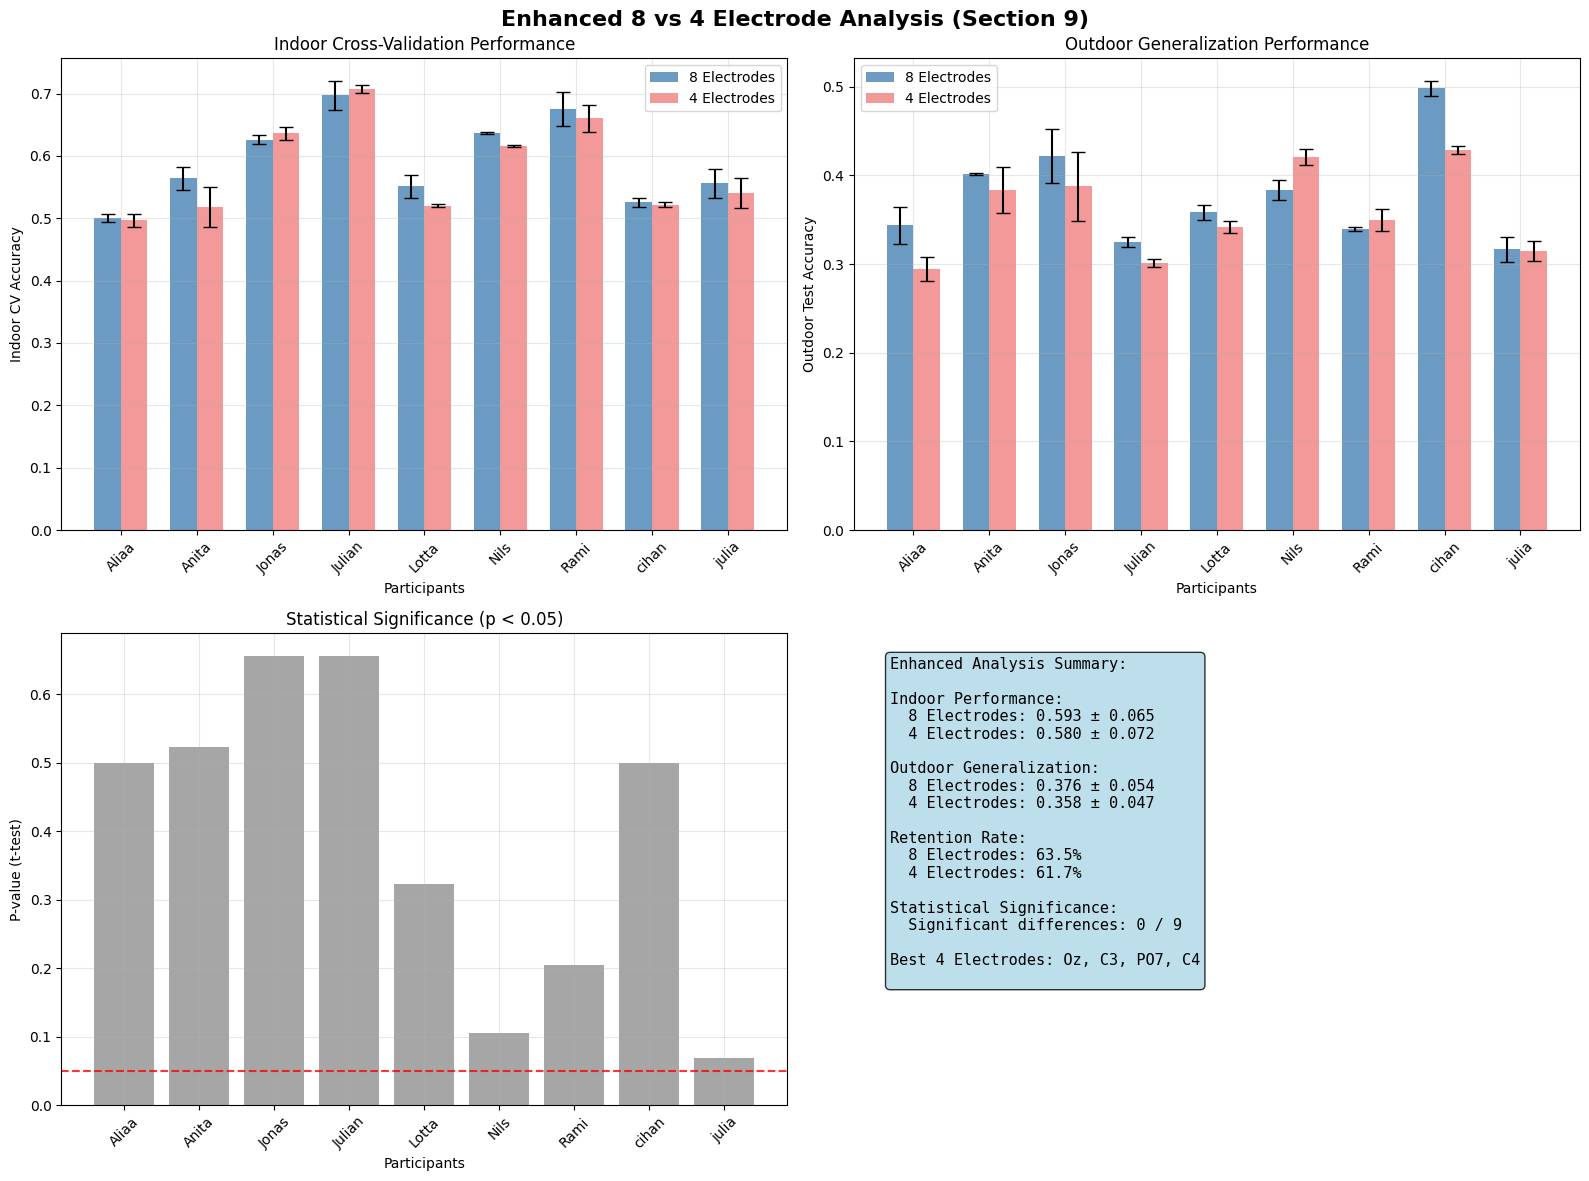

Section 9 visualization saved: section9_enhanced_analysis_indoor.png


In [145]:
# Section 9 Visualization: Enhanced 8 vs 4 Electrode Analysis
import os

# Load enhanced analysis data from the CSV we just created
enhanced_data_loaded = False

if 'RESULTS_DIR' in globals() and 'ANALYSIS_SESSION' in globals():
    csv_path = RESULTS_DIR / f"enhanced_electrode_comparison_{ANALYSIS_SESSION}.csv"
    if csv_path.exists():
        try:
            enhanced_df = pd.read_csv(csv_path)
            print(f"Loaded enhanced analysis data: {len(enhanced_df)} participants")
            enhanced_data_loaded = True
        except Exception as e:
            print(f"Error loading CSV: {e}")
    else:
        print(f"CSV file not found: {csv_path}")

if enhanced_data_loaded and not enhanced_df.empty:
    # Create a comprehensive visualization for the enhanced analysis
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Enhanced 8 vs 4 Electrode Analysis (Section 9)', fontsize=16, fontweight='bold')
    
    # Extract data for visualization using correct column names
    participants_8v4 = enhanced_df['participant'].tolist()
    indoor_8_scores = enhanced_df['indoor_cv_8_mean'].tolist()
    indoor_4_scores = enhanced_df['indoor_cv_4_mean'].tolist()
    outdoor_8_scores = enhanced_df['outdoor_test_8_mean'].tolist()
    outdoor_4_scores = enhanced_df['outdoor_test_4_mean'].tolist()
    p_values = enhanced_df['p_value'].tolist()
    
    # Extract standard deviations for error bars
    indoor_8_std = enhanced_df['indoor_cv_8_std'].tolist()
    indoor_4_std = enhanced_df['indoor_cv_4_std'].tolist()
    outdoor_8_std = enhanced_df['outdoor_test_8_std'].tolist()
    outdoor_4_std = enhanced_df['outdoor_test_4_std'].tolist()
    
    if participants_8v4:
        # Plot 1: Indoor Performance Comparison
        ax1 = axes[0, 0]
        x_pos = range(len(participants_8v4))
        width = 0.35
        
        bars1 = ax1.bar([x - width/2 for x in x_pos], indoor_8_scores, width, 
                       label='8 Electrodes', color='steelblue', alpha=0.8,
                       yerr=indoor_8_std, capsize=5)
        bars2 = ax1.bar([x + width/2 for x in x_pos], indoor_4_scores, width,
                       label='4 Electrodes', color='lightcoral', alpha=0.8,
                       yerr=indoor_4_std, capsize=5)
        
        ax1.set_xlabel('Participants')
        ax1.set_ylabel('Indoor CV Accuracy')
        ax1.set_title('Indoor Cross-Validation Performance')
        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(participants_8v4, rotation=45)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Outdoor Generalization
        ax2 = axes[0, 1]
        bars3 = ax2.bar([x - width/2 for x in x_pos], outdoor_8_scores, width,
                       label='8 Electrodes', color='steelblue', alpha=0.8,
                       yerr=outdoor_8_std, capsize=5)
        bars4 = ax2.bar([x + width/2 for x in x_pos], outdoor_4_scores, width,
                       label='4 Electrodes', color='lightcoral', alpha=0.8,
                       yerr=outdoor_4_std, capsize=5)
        
        ax2.set_xlabel('Participants')
        ax2.set_ylabel('Outdoor Test Accuracy')
        ax2.set_title('Outdoor Generalization Performance')
        ax2.set_xticks(x_pos)
        ax2.set_xticklabels(participants_8v4, rotation=45)
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # Plot 3: Statistical Significance
        ax3 = axes[1, 0]
        significant = [p < 0.05 for p in p_values]
        colors = ['red' if sig else 'gray' for sig in significant]
        
        bars5 = ax3.bar(x_pos, p_values, color=colors, alpha=0.7)
        ax3.axhline(y=0.05, color='red', linestyle='--', alpha=0.8)
        ax3.set_xlabel('Participants')
        ax3.set_ylabel('P-value (t-test)')
        ax3.set_title('Statistical Significance (p < 0.05)')
        ax3.set_xticks(x_pos)
        ax3.set_xticklabels(participants_8v4, rotation=45)
        ax3.grid(True, alpha=0.3)
        
        # Plot 4: Performance Summary
        ax4 = axes[1, 1]
        ax4.axis('off')
        
        # Calculate summary statistics
        mean_indoor_8 = np.mean(indoor_8_scores)
        mean_indoor_4 = np.mean(indoor_4_scores)
        mean_outdoor_8 = np.mean(outdoor_8_scores)
        mean_outdoor_4 = np.mean(outdoor_4_scores)
        sig_count = sum(significant)
        
        # Handle division by zero for retention rate
        retention_8 = (mean_outdoor_8/mean_indoor_8)*100 if mean_indoor_8 > 0 else 0
        retention_4 = (mean_outdoor_4/mean_indoor_4)*100 if mean_indoor_4 > 0 else 0
        
        # Get best 4 electrodes from the data
        best_4_from_data = enhanced_df['best_4_electrodes'].iloc[0] if 'best_4_electrodes' in enhanced_df.columns else 'Not available'
        
        summary_text = f"""Enhanced Analysis Summary:
        
Indoor Performance:
  8 Electrodes: {mean_indoor_8:.3f} ± {np.std(indoor_8_scores):.3f}
  4 Electrodes: {mean_indoor_4:.3f} ± {np.std(indoor_4_scores):.3f}
  
Outdoor Generalization:
  8 Electrodes: {mean_outdoor_8:.3f} ± {np.std(outdoor_8_scores):.3f}
  4 Electrodes: {mean_outdoor_4:.3f} ± {np.std(outdoor_4_scores):.3f}
  
Retention Rate:
  8 Electrodes: {retention_8:.1f}%
  4 Electrodes: {retention_4:.1f}%
  
Statistical Significance:
  Significant differences: {sig_count} / {len(participants_8v4)}
  
Best 4 Electrodes: {best_4_from_data}
        """
        
        ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes, 
                fontsize=11, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    plt.tight_layout()
    filename = f'section9_enhanced_analysis_{ANALYSIS_SESSION.lower()}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Section 9 visualization saved: {filename}")
    
else:
    print("No enhanced analysis data available. Please ensure Section 8 ran successfully.")

## 10) Summary and Additional Analysis

In [146]:
# Section 10: Display summary of enhanced results
if 'enhanced_results' in globals() and enhanced_results:
    df = pd.DataFrame(enhanced_results)
    
    print("=== ENHANCED ANALYSIS SUMMARY ===")
    print("Indoor CV (mean ± std):")
    print("  8-elec:", df['indoor_cv_8_mean'].mean().round(3), '±', df['indoor_cv_8_std'].mean().round(3))
    print("  4-elec:", df['indoor_cv_4_mean'].mean().round(3), '±', df['indoor_cv_4_std'].mean().round(3))
    print("Significant differences:", int((df['p_value'] < 0.05).sum()), '/', len(df))

    if (df['outdoor_available'] == True).any():
        odf = df[df['outdoor_available'] == True]
        print("Outdoor test (mean ± std):")
        print("  8-elec:", odf['outdoor_test_8_mean'].mean().round(3), '±', odf['outdoor_test_8_std'].mean().round(3))
        print("  4-elec:", odf['outdoor_test_4_mean'].mean().round(3), '±', odf['outdoor_test_4_std'].mean().round(3))
        print("Retention (% of indoor):")
        print("  8-elec:", (odf['generalization_ratio_8'].mean()*100).round(1))
        print("  4-elec:", (odf['generalization_ratio_4'].mean()*100).round(1))
    
    # Confirm CSV file exists
    if 'RESULTS_DIR' in globals() and 'ANALYSIS_SESSION' in globals():
        csv_path = RESULTS_DIR / f"enhanced_electrode_comparison_{ANALYSIS_SESSION}.csv"
        if csv_path.exists():
            print(f"Enhanced results CSV confirmed: {csv_path}")
        else:
            print(f"CSV file missing: {csv_path}")
else:
    print("No enhanced results available for summary.")

=== ENHANCED ANALYSIS SUMMARY ===
Indoor CV (mean ± std):
  8-elec: 0.593 ± 0.015
  4-elec: 0.58 ± 0.012
Significant differences: 0 / 9
Outdoor test (mean ± std):
  8-elec: 0.376 ± 0.011
  4-elec: 0.358 ± 0.014
Retention (% of indoor):
  8-elec: 64.6
  4-elec: 62.6
Enhanced results CSV confirmed: results\enhanced_electrode_comparison_indoor.csv


Available columns in all_results_df: ['participant', 'session_type', 'condition', 'excluded_electrode', 'accuracy_mean', 'accuracy_std', 'accuracy_drop']


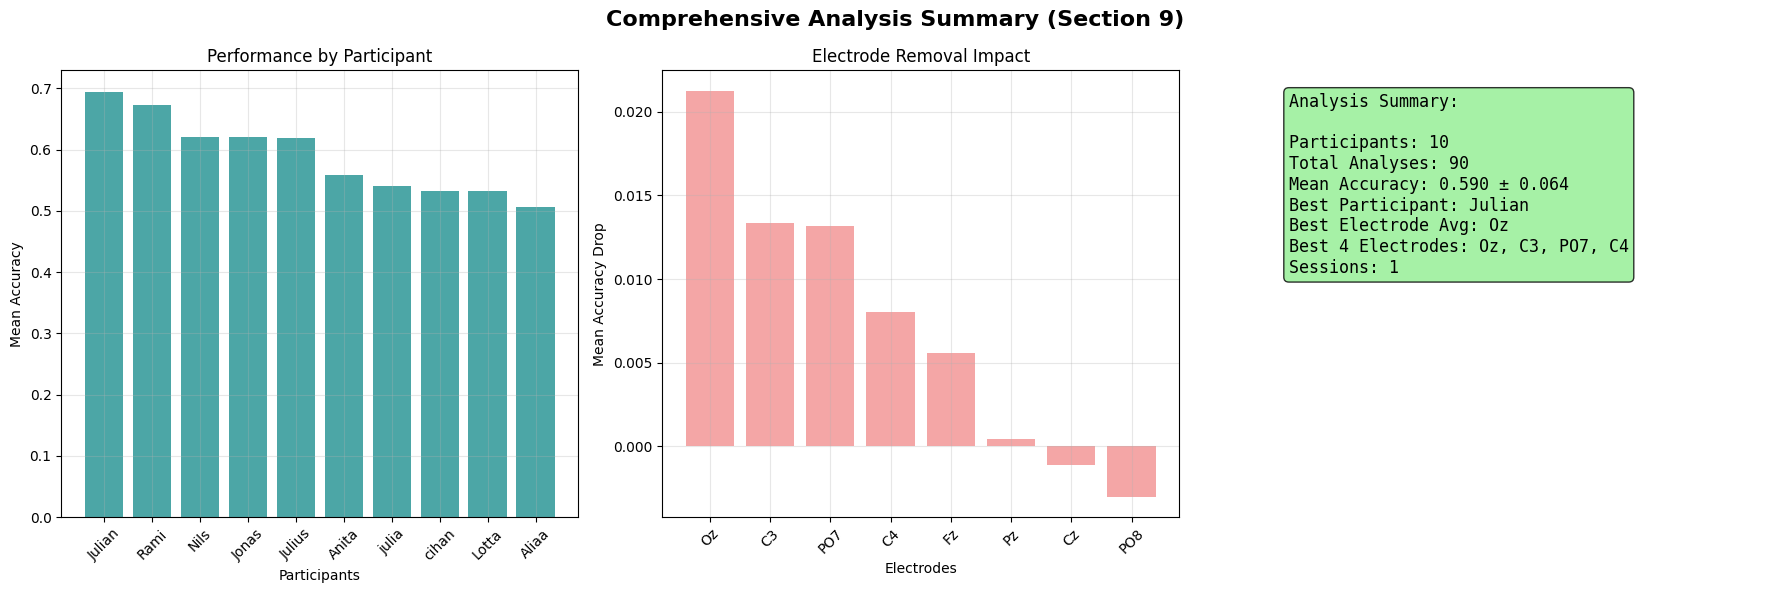

Section 9 visualization saved: section9_summary_visualization_indoor.png


In [147]:
# Section 9 Visualization: Comprehensive Analysis Summary

if 'all_results_df' in globals() and not all_results_df.empty:
    # Check what columns are available
    print("Available columns in all_results_df:", list(all_results_df.columns))
    
    # Generate the comprehensive summary visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Comprehensive Analysis Summary (Section 9)', fontsize=16, fontweight='bold')
    
    # Use the correct column name for accuracy
    accuracy_col = 'accuracy_mean' if 'accuracy_mean' in all_results_df.columns else 'accuracy'
    
    # Plot 1: Performance by Participant
    ax1 = axes[0]
    participant_summary = all_results_df.groupby('participant')[accuracy_col].mean().sort_values(ascending=False)
    
    bars = ax1.bar(range(len(participant_summary)), participant_summary.values, alpha=0.7, color='teal')
    ax1.set_title('Performance by Participant')
    ax1.set_ylabel('Mean Accuracy')
    ax1.set_xlabel('Participants')
    ax1.set_xticks(range(len(participant_summary)))
    ax1.set_xticklabels(participant_summary.index, rotation=45)
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Electrode Removal Impact
    ax2 = axes[1]
    if 'excluded_electrode' in all_results_df.columns and 'accuracy_drop' in all_results_df.columns:
        loo_data = all_results_df[all_results_df['condition'] == 'leave_one_out']
        if not loo_data.empty:
            drops_by_el = loo_data.groupby('excluded_electrode')['accuracy_drop'].mean().sort_values(ascending=False)
            
            bars = ax2.bar(range(len(drops_by_el)), drops_by_el.values, alpha=0.7, color='lightcoral')
            ax2.set_title('Electrode Removal Impact')
            ax2.set_ylabel('Mean Accuracy Drop')
            ax2.set_xlabel('Electrodes')
            ax2.set_xticks(range(len(drops_by_el)))
            ax2.set_xticklabels(drops_by_el.index, rotation=45)
            ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, 'No leave-one-out data available', 
                    ha='center', va='center', transform=ax2.transAxes)
    else:
        ax2.text(0.5, 0.5, 'Electrode analysis data not available', 
                ha='center', va='center', transform=ax2.transAxes)
    
    # Plot 3: Summary Statistics Box
    ax3 = axes[2]
    ax3.axis('off')
    
    # Calculate overall statistics
    overall_stats = {
        'n_participants': all_results_df['participant'].nunique(),
        'n_total_analyses': len(all_results_df),
        'mean_accuracy': all_results_df[accuracy_col].mean(),
        'std_accuracy': all_results_df[accuracy_col].std(),
        'best_participant': all_results_df.groupby('participant')[accuracy_col].mean().idxmax(),
        'best_electrode_avg': None,
        'n_sessions': all_results_df['session_type'].nunique() if 'session_type' in all_results_df.columns else 1
    }
    
    # Best electrode info
    if 'excluded_electrode' in all_results_df.columns and 'accuracy_drop' in all_results_df.columns:
        loo_data = all_results_df[all_results_df['condition'] == 'leave_one_out']
        if not loo_data.empty:
            overall_stats['best_electrode_avg'] = loo_data.groupby('excluded_electrode')['accuracy_drop'].mean().idxmax()
    
    stats_text = f"""Analysis Summary:

Participants: {overall_stats['n_participants']}
Total Analyses: {overall_stats['n_total_analyses']}
Mean Accuracy: {overall_stats['mean_accuracy']:.3f} ± {overall_stats['std_accuracy']:.3f}
Best Participant: {overall_stats['best_participant']}
Best Electrode Avg: {overall_stats['best_electrode_avg'] if overall_stats['best_electrode_avg'] else 'N/A'}
Best 4 Electrodes: {', '.join(best_4_electrodes) if 'best_4_electrodes' in globals() and best_4_electrodes else 'N/A'}
Sessions: {overall_stats['n_sessions']}"""
    
    ax3.text(0.05, 0.95, stats_text, transform=ax3.transAxes, fontsize=12,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    
    plt.tight_layout()
    filename = f'section9_summary_visualization_{ANALYSIS_SESSION.lower()}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Section 9 visualization saved: {filename}")
    
else:
    print("No analysis results available. Please run the main analysis first.")

## 10) Outdoor-Only Analysis: 8 vs 4 Electrodes

This section performs the same 8 vs 4 electrode comparison but trains and tests exclusively on outdoor data. This allows direct comparison of electrode importance in outdoor conditions and complements the indoor→outdoor generalization analysis above. This section was added after the end of the course on the 10th of september and is meant as an extension of the analysis in section 8).

In [148]:
def compare_8vs4_electrodes_outdoor_only(participant, best_4_electrodes):
    """
    Compare 8 vs 4 electrodes using outdoor data only for both training and testing.
    This provides insight into electrode importance specifically in outdoor conditions.
    """
    outdoor_epochs = load_participant_session(participant, "outdoor")
    if outdoor_epochs is None:
        return None

    y_outdoor = outdoor_epochs.metadata["difficulty"].astype(int).to_numpy()

    # 8-elec outdoor CV
    X8, _, _ = extract_features(outdoor_epochs)
    m8, s8, scores8, models8 = train_and_evaluate_rf_with_models(X8, y_outdoor)

    # 4-elec outdoor CV  
    worst4 = [el for el in ALL_ELECTRODES if el not in best_4_electrodes]
    X4, _, _ = extract_features(outdoor_epochs, exclude_channels=worst4)
    m4, s4, scores4, models4 = train_and_evaluate_rf_with_models(X4, y_outdoor)

    # Paired t-test on outdoor CV scores
    t_stat, p_value = stats.ttest_rel(scores8, scores4)

    return {
        'participant': participant,
        'best_4_electrodes': ', '.join(best_4_electrodes),
        'outdoor_cv_8_mean': m8, 'outdoor_cv_8_std': s8, 'outdoor_cv_8_scores': scores8,
        'outdoor_cv_4_mean': m4, 'outdoor_cv_4_std': s4, 'outdoor_cv_4_scores': scores4,
        't_statistic': t_stat, 'p_value': p_value,
        'outdoor_difference_8_minus_4': m8 - m4,
        'significant_improvement': p_value < 0.05 and m8 > m4,
    }

In [149]:
# Execute outdoor-only analysis
outdoor_only_results = []

if 'all_results_df' in globals() and not all_results_df.empty:
    # Use the same best 4 electrodes as determined earlier
    if 'best_4_electrodes' not in globals() or not best_4_electrodes:
        loo = all_results_df[all_results_df['condition']=='leave_one_out']
        drops = (loo.groupby('excluded_electrode')['accuracy_drop']
                   .mean()
                   .sort_values(ascending=False))
        best_4_electrodes = list(drops.index[:4])

    print("Best 4 electrodes for outdoor-only analysis:", best_4_electrodes)

    # Find participants with outdoor data
    participants_with_outdoor = []
    for p in get_available_participants():
        d = Path(DATA_DIRECTORY)/p
        if (d/"outdoor_processed-epo.fif").exists():
            participants_with_outdoor.append(p)

    print(f"Participants with outdoor data: {participants_with_outdoor}")

    for p in participants_with_outdoor:
        r = compare_8vs4_electrodes_outdoor_only(p, best_4_electrodes)
        if r:
            outdoor_only_results.append(r)

    print(f"Completed {len(outdoor_only_results)}/{len(participants_with_outdoor)} outdoor-only comparisons")

else:
    print("No base results available; run sections 5-8 first.")

Best 4 electrodes for outdoor-only analysis: ['Oz', 'C3', 'PO7', 'C4']
Participants with outdoor data: ['Abdullah', 'Aliaa', 'Anita', 'Jonas', 'Julian', 'Lotta', 'Moritz', 'Nils', 'Rami', 'cihan', 'julia']
Adding metadata with 3 columns
Loaded Abdullah outdoor: 604 epochs
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 samples (1.652 s)

Loaded Abdullah outdoor: 604 epochs
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain 

=== OUTDOOR-ONLY ANALYSIS SUMMARY ===
Outdoor CV Performance (mean ± std):
  8-elec: 0.553 ± 0.017
  4-elec: 0.528 ± 0.015
  Difference (8-4): 0.026
Statistically significant differences: 0/11
Significant improvements (8 > 4): 0/11
Saved: results\outdoor_only_electrode_comparison.png
Saved: results\outdoor_only_electrode_comparison.png


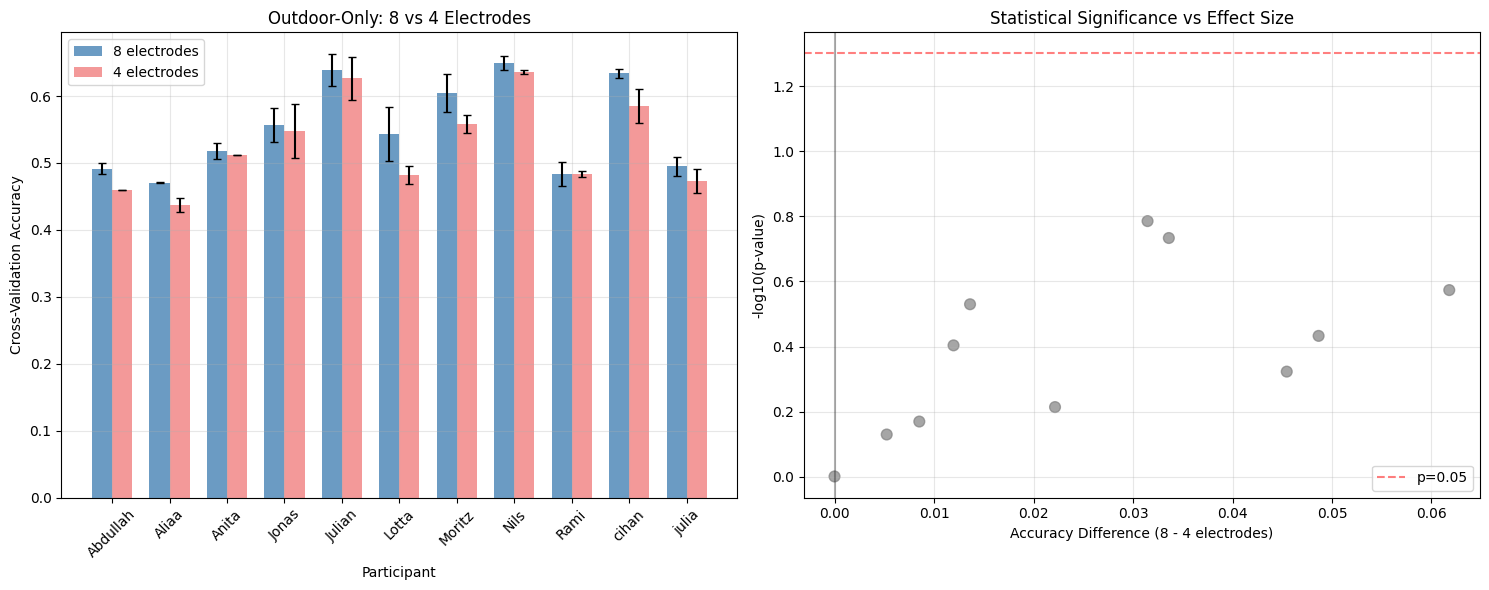

Saved: results\outdoor_only_electrode_comparison.csv


In [150]:
def summarize_outdoor_only_results(outdoor_only_results):
    """Summarize and visualize the outdoor-only 8 vs 4 electrode comparison results."""
    if not outdoor_only_results:
        print("No outdoor-only results available.")
        return None

    df = pd.DataFrame(outdoor_only_results)
    
    print("=== OUTDOOR-ONLY ANALYSIS SUMMARY ===")
    print("Outdoor CV Performance (mean ± std):")
    print("  8-elec:", df['outdoor_cv_8_mean'].mean().round(3), '±', df['outdoor_cv_8_std'].mean().round(3))
    print("  4-elec:", df['outdoor_cv_4_mean'].mean().round(3), '±', df['outdoor_cv_4_std'].mean().round(3))
    print("  Difference (8-4):", df['outdoor_difference_8_minus_4'].mean().round(3))
    
    significant_count = int((df['p_value'] < 0.05).sum())
    print(f"Statistically significant differences: {significant_count}/{len(df)}")
    
    improvement_count = int(df['significant_improvement'].sum())
    print(f"Significant improvements (8 > 4): {improvement_count}/{len(df)}")

    # Create comparison visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Bar plot of mean accuracies
    participants = [p.replace('sub-', '') for p in df['participant']]
    x = np.arange(len(participants))
    width = 0.35
    
    ax1.bar(x - width/2, df['outdoor_cv_8_mean'], width, 
            label='8 electrodes', alpha=0.8, color='steelblue',
            yerr=df['outdoor_cv_8_std'], capsize=3)
    ax1.bar(x + width/2, df['outdoor_cv_4_mean'], width,
            label='4 electrodes', alpha=0.8, color='lightcoral',
            yerr=df['outdoor_cv_4_std'], capsize=3)
    
    ax1.set_xlabel('Participant')
    ax1.set_ylabel('Cross-Validation Accuracy')
    ax1.set_title('Outdoor-Only: 8 vs 4 Electrodes')
    ax1.set_xticks(x)
    ax1.set_xticklabels(participants, rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Scatter plot of differences vs p-values
    colors = ['red' if sig else 'gray' for sig in df['significant_improvement']]
    ax2.scatter(df['outdoor_difference_8_minus_4'], -np.log10(df['p_value']), 
                c=colors, alpha=0.7, s=60)
    ax2.axhline(-np.log10(0.05), color='red', linestyle='--', alpha=0.5, label='p=0.05')
    ax2.axvline(0, color='black', linestyle='-', alpha=0.3)
    ax2.set_xlabel('Accuracy Difference (8 - 4 electrodes)')
    ax2.set_ylabel('-log10(p-value)')
    ax2.set_title('Statistical Significance vs Effect Size')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    out = RESULTS_DIR / "outdoor_only_electrode_comparison.png"
    plt.savefig(out, dpi=300, bbox_inches='tight')
    print("Saved:", out)
    plt.show()

    # Save CSV
    out_csv = RESULTS_DIR / "outdoor_only_electrode_comparison.csv"
    df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)
    
    return out_csv

# Generate summary and visualization
_ = summarize_outdoor_only_results(outdoor_only_results)

In [151]:
def summarize_enhanced_results(enhanced_results):

    if not enhanced_results:

        print("No enhanced results available.")

        return None

    df = pd.DataFrame(enhanced_results)

    print("Indoor CV (mean ± std):")

    print("  8-elec:", df['indoor_cv_8_mean'].mean().round(3), '±', df['indoor_cv_8_std'].mean().round(3))

    print("  4-elec:", df['indoor_cv_4_mean'].mean().round(3), '±', df['indoor_cv_4_std'].mean().round(3))

    print("Significant differences:", int((df['p_value'] < 0.05).sum()), '/', len(df))

    if (df['outdoor_available'] == True).any():

        odf = df[df['outdoor_available'] == True]

        print("Outdoor test (mean ± std):")

        print("  8-elec:", odf['outdoor_test_8_mean'].mean().round(3), '±', odf['outdoor_test_8_std'].mean().round(3))

        print("  4-elec:", odf['outdoor_test_4_mean'].mean().round(3), '±', odf['outdoor_test_4_std'].mean().round(3))

        print("Retention (% of indoor):")

        print("  8-elec:", (odf['generalization_ratio_8'].mean()*100).round(1))

        print("  4-elec:", (odf['generalization_ratio_4'].mean()*100).round(1))

    # Save CSV

    out = RESULTS_DIR / f"enhanced_electrode_comparison_{ANALYSIS_SESSION}.csv"

    pd.DataFrame(enhanced_results).to_csv(out, index=False)

    print("Saved:", out)

    return out



_ = summarize_enhanced_results(enhanced_results)

Indoor CV (mean ± std):
  8-elec: 0.593 ± 0.015
  4-elec: 0.58 ± 0.012
Significant differences: 0 / 9
Outdoor test (mean ± std):
  8-elec: 0.376 ± 0.011
  4-elec: 0.358 ± 0.014
Retention (% of indoor):
  8-elec: 64.6
  4-elec: 62.6
Saved: results\enhanced_electrode_comparison_indoor.csv


## 11) Confusion Matrix Analysis (8 vs 4 Electrodes)

The confusion matrix lets you take a look at the prediction to classification ratios between the different n-back-task difficulties and the tested subset of electrodes. Please note that this section was not included on the poster due to lack of space on the poster. 

In [152]:
from sklearn.model_selection import cross_val_predict

from sklearn.metrics import confusion_matrix, classification_report



def train_and_evaluate_rf_with_confusion_matrix(X, y, cv_folds=5):

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X)

    selector = None

    if X_scaled.shape[1] > 20:

        selector = SelectKBest(score_func=f_classif, k=20)

        X_selected = selector.fit_transform(X_scaled, y)

    else:

        X_selected = X_scaled

    min_class = np.bincount(y).min()

    n_splits = min(cv_folds, int(min_class)) if min_class > 1 else 2

    rf = RandomForestClassifier(n_estimators=1000, min_samples_split=4, min_samples_leaf=6,

                               class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)

    y_pred = cross_val_predict(rf, X_selected, y, cv=cv, n_jobs=-1)

    cm = confusion_matrix(y, y_pred, labels=sorted(np.unique(y)))

    scores = cross_val_score(rf, X_selected, y, cv=cv, scoring="accuracy", n_jobs=-1)

    return scores.mean(), scores.std(), scores, cm, y, y_pred



def compare_8vs4_electrodes_with_confusion_matrix(participant, session_type, best_4_electrodes):

    epochs = load_participant_session(participant, session_type)

    if epochs is None:

        return None

    y = epochs.metadata["difficulty"].astype(int).to_numpy()

    diff_map = {0:'0-back', 1:'1-back', 2:'2-back', 3:'3-back'} if INCLUDE_0_BACK else {1:'1-back', 2:'2-back', 3:'3-back'}

    labels = [diff_map[i] for i in sorted(np.unique(y))]

    # 8-elec

    X8, _, _ = extract_features(epochs)

    acc8, std8, _, cm8, y_true, y_pred8 = train_and_evaluate_rf_with_confusion_matrix(X8, y)

    # 4-elec

    worst4 = [el for el in ALL_ELECTRODES if el not in best_4_electrodes]

    X4, _, _ = extract_features(epochs, exclude_channels=worst4)

    acc4, std4, _, cm4, _, y_pred4 = train_and_evaluate_rf_with_confusion_matrix(X4, y)

    return {

        'participant': participant,

        'session_type': session_type,

        'cm_8_electrodes': cm8,

        'cm_4_electrodes': cm4,

        'acc_8': acc8,

        'acc_4': acc4,

        'acc_8_std': std8,

        'acc_4_std': std4,

        'difficulty_labels': labels,

        'y_true': y_true,

        'y_pred_8': y_pred8,

        'y_pred_4': y_pred4,

        'best_4_electrodes': ', '.join(best_4_electrodes),

        'accuracy_difference': acc8 - acc4,

    }

In [153]:
# Run confusion matrix analysis 
cm_results = []

if 'all_results_df' in globals() and not all_results_df.empty:
    # Use the same best 4 electrodes as in the enhanced section
    if 'best_4_electrodes' not in globals() or not best_4_electrodes:
        loo = all_results_df[all_results_df['condition']=='leave_one_out']
        drops = (loo.groupby('excluded_electrode')['accuracy_drop']
                   .mean()
                   .sort_values(ascending=False))
        best_4_electrodes = list(drops.index[:4])

    print("Best 4 electrodes:", best_4_electrodes)

    participants = get_available_participants()
    for p in participants:
        r = compare_8vs4_electrodes_with_confusion_matrix(p, ANALYSIS_SESSION, best_4_electrodes)
        if r:
            cm_results.append(r)

    print(f"Completed {len(cm_results)}/{len(participants)} confusion matrix analyses")

else:
    print("No base results available; run sections 5-8 first.")

Best 4 electrodes: ['Oz', 'C3', 'PO7', 'C4']
Missing file for Abdullah indoor: C:\Users\morit\OneDrive\Desktop\Uni\Master Neuroscience\Semester 2\BPR\BPR Git\eeg-brain-interface\Abgabe\results\Abdullah\indoor_processed-epo.fif
Adding metadata with 3 columns
Adding metadata with 3 columns
Loaded Aliaa indoor: 600 epochs
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 413 samples (1.652 s)

Loaded Aliaa indoor: 600 epochs
Setting up band-pass filter from 4 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-cau

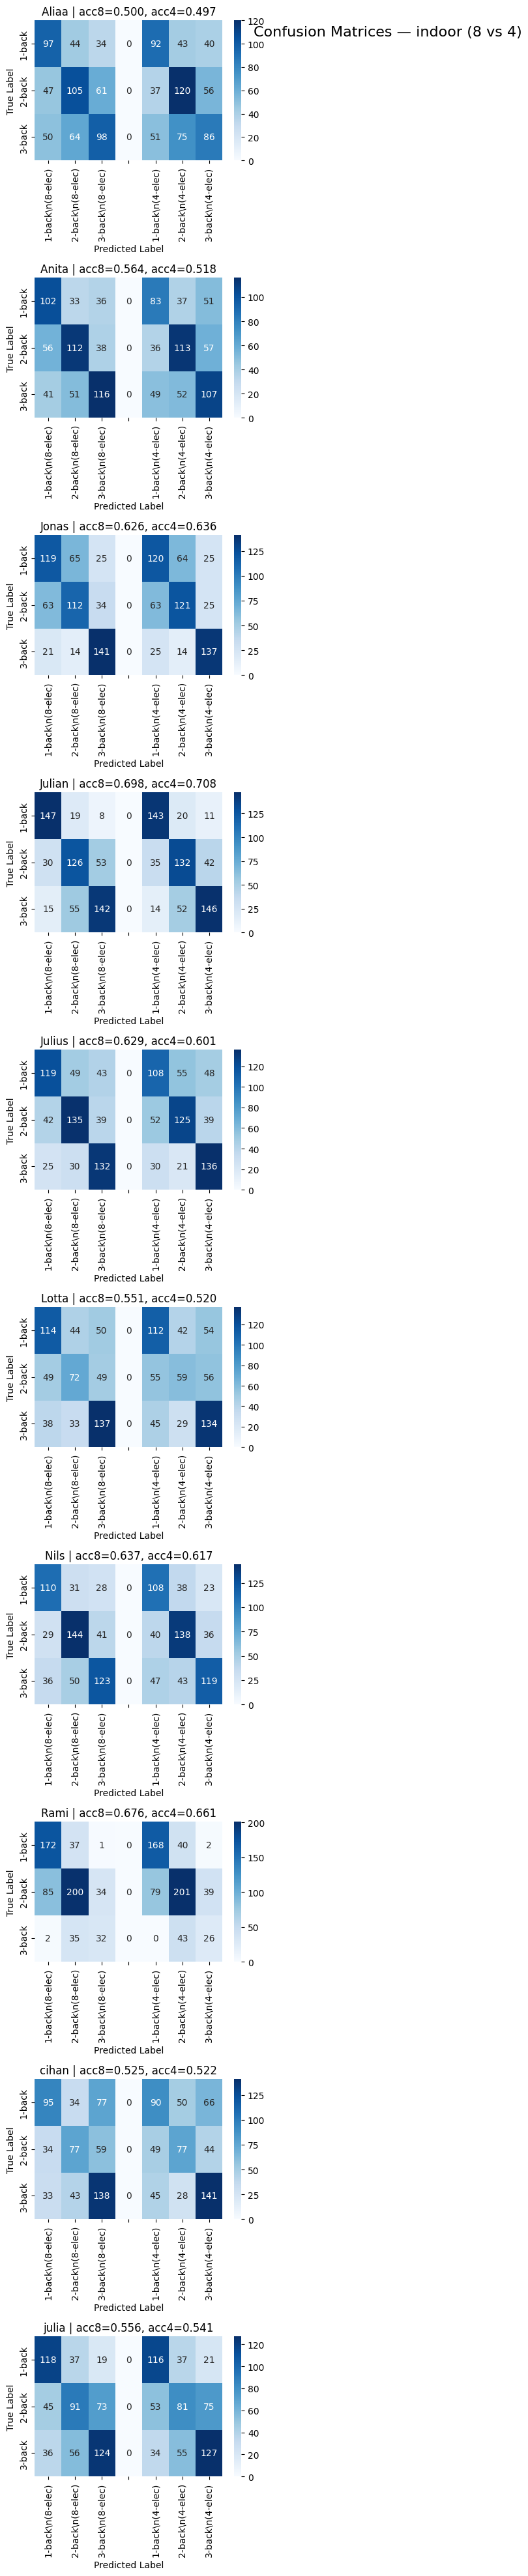

\n=== indoor Confusion Matrix Analysis ===
\nDetailed Results:
Participant Accuracy_8_Electrodes Accuracy_4_Electrodes Accuracy_Difference Std_8_Electrodes Std_4_Electrodes
      Aliaa                 0.500                 0.497               0.003            0.007            0.010
      Anita                 0.564                 0.518               0.046            0.018            0.032
      Jonas                 0.626                 0.636              -0.010            0.007            0.010
     Julian                 0.698                 0.708              -0.010            0.023            0.006
     Julius                 0.629                 0.601               0.028            0.016            0.028
      Lotta                 0.551                 0.520               0.031            0.019            0.002
       Nils                 0.637                 0.617               0.020            0.002            0.002
       Rami                 0.676                 0.661  

,participant,acc_8,acc_4,acc_diff,best_4_electrodes
0,Aliaa,0.500000,0.496667,0.003333,"Oz, C3, PO7, C4"
1,Anita,0.564133,0.517895,0.046239,"Oz, C3, PO7, C4"
2,Jonas,0.626263,0.636364,-0.010101,"Oz, C3, PO7, C4"
3,Julian,0.697518,0.707573,-0.010056,"Oz, C3, PO7, C4"
4,Julius,0.628664,0.600977,0.027687,"Oz, C3, PO7, C4"


In [154]:
def create_confusion_matrix_visualization(cm_results, session_type='Indoor'):
    """Create and save confusion matrix visualization comparing 8 vs 4 electrodes"""
    
    if not cm_results:
        print("No confusion matrix results to visualize")
        return
    
    n_participants = len(cm_results)
    n_cols = 3  # 8-elec, spacer, 4-elec
    
    # Create subplot grid: 3 columns x n_participants rows
    fig, axes = plt.subplots(n_participants, n_cols, figsize=(12, 4*n_participants))
    if n_participants == 1:
        axes = axes.reshape(1, -1)
    
    # Process each participant
    for i, result in enumerate(cm_results):
        # Extract confusion matrices and data
        cm8 = result['cm_8_electrodes']
        cm4 = result['cm_4_electrodes']
        difficulty_labels = result['difficulty_labels']
        participant = result['participant']
        acc8 = result['acc_8']
        acc4 = result['acc_4']
        
        ax = axes[i, 0] if n_participants > 1 else axes[0]
        
        # Create combined matrix with spacer column for visual separation
        combined = np.hstack([cm8, np.zeros((cm8.shape[0], 1)), cm4])
        xticks = [f'{l}\\n(8-elec)' for l in difficulty_labels] + [''] + [f'{l}\\n(4-elec)' for l in difficulty_labels]
        
        sns.heatmap(combined, annot=True, fmt='.0f', cmap='Blues', ax=ax,
                   xticklabels=xticks, yticklabels=difficulty_labels, cbar=True)
        
        ax.set_title(f'{participant} | acc8={acc8:.3f}, acc4={acc4:.3f}')
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')
        
        # Hide middle and right subplots for this row (we only use the first column)
        if n_participants > 1:
            axes[i, 1].set_visible(False)
            axes[i, 2].set_visible(False)
        else:
            axes[1].set_visible(False)
            axes[2].set_visible(False)
    
    plt.suptitle(f'Confusion Matrices — {session_type} (8 vs 4)', fontsize=16, y=0.98)
    plt.tight_layout()
    
    # Save the figure
    filename = f'confusion_matrices_{session_type.lower()}_8v4.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    return filename

def create_detailed_confusion_matrix_analysis(cm_results, session_type='Indoor'):
    """Create detailed analysis tables from confusion matrix results"""
    
    if not cm_results:
        print("No confusion matrix results to analyze")
        return
    
    # Convert to DataFrame for easier analysis
    cm_df_data = []
    for result in cm_results:
        for i, difficulty in enumerate(result['difficulty_labels']):
            cm_df_data.append({
                'participant': result['participant'],
                'difficulty': difficulty,
                'acc_8': result['acc_8'],
                'acc_4': result['acc_4'],
                'cm_8': result['cm_8_electrodes'],
                'cm_4': result['cm_4_electrodes']
            })
    
    cm_df = pd.DataFrame(cm_df_data)
    
    # Analysis summary table
    summary_data = []
    for result in cm_results:
        summary_data.append({
            'Participant': result['participant'],
            'Accuracy_8_Electrodes': f"{result['acc_8']:.3f}",
            'Accuracy_4_Electrodes': f"{result['acc_4']:.3f}",
            'Accuracy_Difference': f"{result['acc_8'] - result['acc_4']:.3f}",
            'Std_8_Electrodes': f"{result.get('acc_8_std', 0):.3f}",
            'Std_4_Electrodes': f"{result.get('acc_4_std', 0):.3f}"
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    # Calculate overall statistics
    acc_8_values = [r['acc_8'] for r in cm_results]
    acc_4_values = [r['acc_4'] for r in cm_results]
    acc_diff_values = [r['acc_8'] - r['acc_4'] for r in cm_results]
    
    overall_stats = {
        'Mean_Accuracy_8_Electrodes': f"{np.mean(acc_8_values):.3f}",
        'Mean_Accuracy_4_Electrodes': f"{np.mean(acc_4_values):.3f}",
        'Mean_Accuracy_Difference': f"{np.mean(acc_diff_values):.3f}",
        'Std_Accuracy_8_Electrodes': f"{np.std(acc_8_values):.3f}",
        'Std_Accuracy_4_Electrodes': f"{np.std(acc_4_values):.3f}",
        'Std_Accuracy_Difference': f"{np.std(acc_diff_values):.3f}"
    }
    
    print(f"\\n=== {session_type} Confusion Matrix Analysis ===")
    print("\\nDetailed Results:")
    print(summary_df.to_string(index=False))
    
    print("\\nOverall Statistics:")
    for key, value in overall_stats.items():
        print(f"{key.replace('_', ' ')}: {value}")
    
    # Export to CSV
    summary_filename = f'confusion_matrix_analysis_{session_type.lower()}.csv'
    summary_df.to_csv(summary_filename, index=False)
    
    print(f"\\nExported: {summary_filename}")
    
    out = {
        'summary_df': summary_df,
        'overall_stats': overall_stats,
        'cm_df': cm_df,
        'files': [summary_filename]
    }
    
    return out

# Visualize and export summaries
_ = create_confusion_matrix_visualization(cm_results, ANALYSIS_SESSION)
_ = create_detailed_confusion_matrix_analysis(cm_results, ANALYSIS_SESSION)

# Export compact summary CSV
cm_summary = []
for result in cm_results:
    cm_summary.append({
        'participant': result['participant'],
        'acc_8': result['acc_8'],
        'acc_4': result['acc_4'],
        'acc_diff': result['acc_8'] - result['acc_4'],
        'best_4_electrodes': str(result['best_4_electrodes'])
    })

cm_summary_df = pd.DataFrame(cm_summary)
summary_file = f'confusion_matrix_summary_{ANALYSIS_SESSION.lower()}.csv'
cm_summary_df.to_csv(summary_file, index=False)
print(f"\\nCompact summary exported: {summary_file}")

# Display final summary statistics
acc_8_values = [r['acc_8'] for r in cm_results]
acc_4_values = [r['acc_4'] for r in cm_results]
acc_diff_values = [r['acc_8'] - r['acc_4'] for r in cm_results]

print(f"\\n=== FINAL {ANALYSIS_SESSION} SUMMARY ===")
print(f"8-Electrode Mean Accuracy: {np.mean(acc_8_values):.3f} ± {np.std(acc_8_values):.3f}")
print(f"4-Electrode Mean Accuracy: {np.mean(acc_4_values):.3f} ± {np.std(acc_4_values):.3f}")
print(f"Mean Improvement (8 vs 4): {np.mean(acc_diff_values):.3f} ± {np.std(acc_diff_values):.3f}")

# Show sample of results
if cm_results:
    print(f"\\nSample results (first participant: {cm_results[0]['participant']}):")
    print(f"  8-electrode accuracy: {cm_results[0]['acc_8']:.3f}")
    print(f"  4-electrode accuracy: {cm_results[0]['acc_4']:.3f}")
    print(f"  Best 4 electrodes: {cm_results[0]['best_4_electrodes']}")
    print(f"  Total participants: {len(cm_results)}")

cm_summary_df.head()

## Overall Confusion Matrix Analysis: Indoor vs Outdoor

This section creates an overall confusion matrix visualization that combines indoor and outdoor data across all participants to show the complete picture of 8 vs 4 electrode performance.

=== OVERALL INDOOR CONFUSION MATRIX ANALYSIS ===

Participants in indoor analysis: 10
   ['Aliaa', 'Anita', 'Jonas', 'Julian', 'Julius', 'Lotta', 'Nils', 'Rami', 'cihan', 'julia']

INDOOR RESULTS (n=10 participants):
   8-electrode accuracy: 0.596
   4-electrode accuracy: 0.582
   Difference (8-4): 0.014


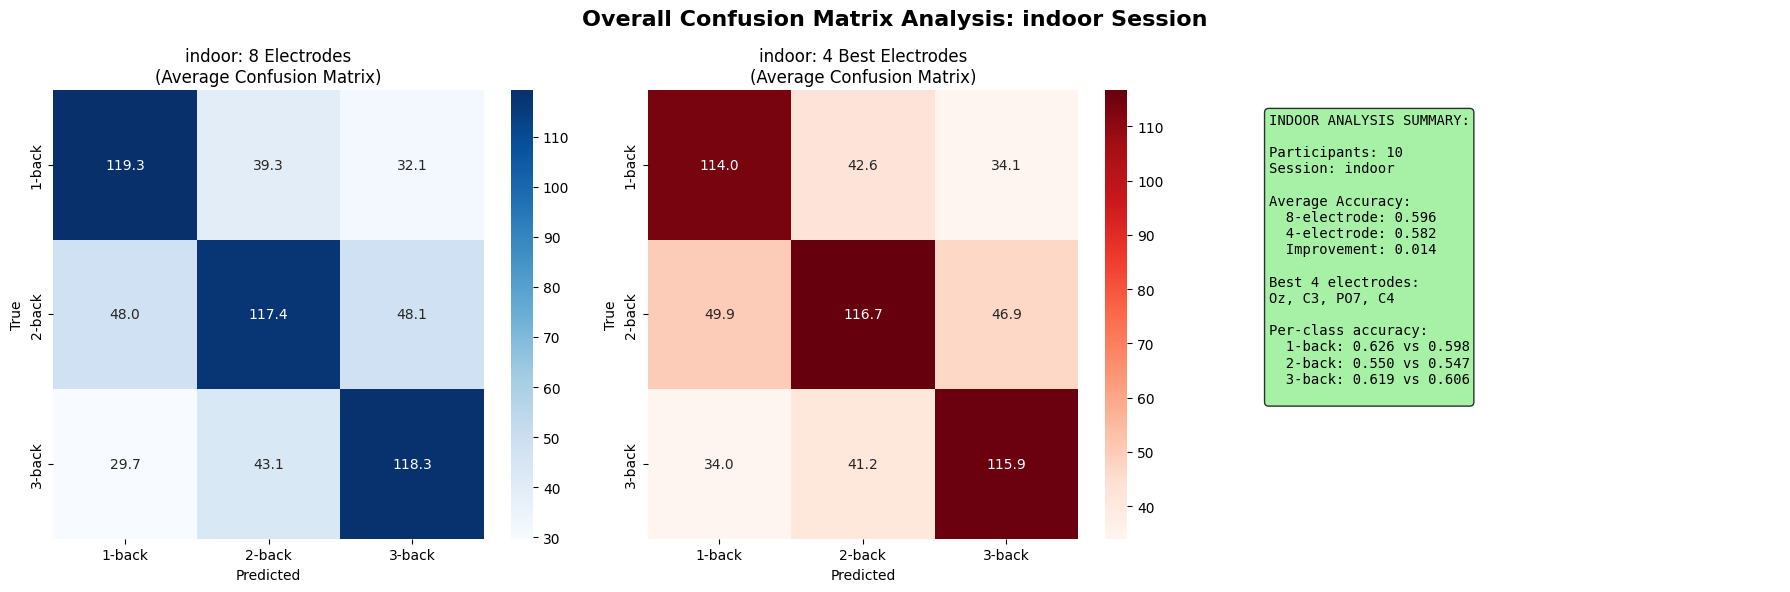


Overall confusion matrix analysis saved: overall_confusion_matrix_indoor.png


In [155]:
def create_overall_confusion_matrix():
    """Create overall confusion matrix for the current analysis session across all participants"""
    
    print(f"=== OVERALL {ANALYSIS_SESSION.upper()} CONFUSION MATRIX ANALYSIS ===\n")
    
    # Check if we have confusion matrix results
    if not cm_results:
        print("No confusion matrix results available for analysis")
        print("Please run the confusion matrix analysis first")
        return
    
    print(f"Participants in {ANALYSIS_SESSION} analysis: {len(cm_results)}")
    participants_list = [r['participant'] for r in cm_results]
    print(f"   {participants_list}\n")
    
    # Create comparison visualization with simpler layout (1 row, 3 columns)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'Overall Confusion Matrix Analysis: {ANALYSIS_SESSION} Session', 
                 fontsize=16, fontweight='bold')
    
    # Extract confusion matrices from cm_results
    cms_8 = []
    cms_4 = []
    
    for result in cm_results:
        cms_8.append(result['cm_8_electrodes'])
        cms_4.append(result['cm_4_electrodes'])
    
    # Calculate average confusion matrices
    avg_cm_8 = np.mean(cms_8, axis=0)
    avg_cm_4 = np.mean(cms_4, axis=0)
    difficulty_labels = cm_results[0]['difficulty_labels']
    
    # Plot 1: 8-electrode average
    ax1 = axes[0]
    sns.heatmap(avg_cm_8, annot=True, fmt='.1f', cmap='Blues', ax=ax1,
               xticklabels=difficulty_labels, yticklabels=difficulty_labels)
    ax1.set_title(f'{ANALYSIS_SESSION}: 8 Electrodes\n(Average Confusion Matrix)')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('True')
    
    # Plot 2: 4-electrode average  
    ax2 = axes[1]
    sns.heatmap(avg_cm_4, annot=True, fmt='.1f', cmap='Reds', ax=ax2,
               xticklabels=difficulty_labels, yticklabels=difficulty_labels)
    ax2.set_title(f'{ANALYSIS_SESSION}: 4 Best Electrodes\n(Average Confusion Matrix)')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('True')
    
    # Plot 3: Summary statistics
    ax3 = axes[2]
    ax3.axis('off')
    
    # Calculate accuracies for summary
    acc_8 = np.mean([np.trace(cm) / np.sum(cm) for cm in cms_8])
    acc_4 = np.mean([np.trace(cm) / np.sum(cm) for cm in cms_4])
    
    print(f"{ANALYSIS_SESSION.upper()} RESULTS (n={len(cms_8)} participants):")
    print(f"   8-electrode accuracy: {acc_8:.3f}")
    print(f"   4-electrode accuracy: {acc_4:.3f}")
    print(f"   Difference (8-4): {acc_8-acc_4:.3f}")
    
    # Create summary text for the plot
    summary_text = f"{ANALYSIS_SESSION.upper()} ANALYSIS SUMMARY:\n\n"
    summary_text += f"Participants: {len(cms_8)}\n"
    summary_text += f"Session: {ANALYSIS_SESSION}\n\n"
    summary_text += f"Average Accuracy:\n"
    summary_text += f"  8-electrode: {acc_8:.3f}\n"
    summary_text += f"  4-electrode: {acc_4:.3f}\n"
    summary_text += f"  Improvement: {acc_8-acc_4:.3f}\n\n"
    
    if 'best_4_electrodes' in globals():
        summary_text += f"Best 4 electrodes:\n{', '.join(best_4_electrodes)}\n\n"
    
    # Add per-class accuracy information
    class_acc_8 = [avg_cm_8[i, i] / avg_cm_8[i, :].sum() if avg_cm_8[i, :].sum() > 0 else 0 
                   for i in range(len(difficulty_labels))]
    class_acc_4 = [avg_cm_4[i, i] / avg_cm_4[i, :].sum() if avg_cm_4[i, :].sum() > 0 else 0 
                   for i in range(len(difficulty_labels))]
    
    summary_text += "Per-class accuracy:\n"
    for i, label in enumerate(difficulty_labels):
        summary_text += f"  {label}: {class_acc_8[i]:.3f} vs {class_acc_4[i]:.3f}\n"
    
    ax3.text(0.05, 0.95, summary_text, transform=ax3.transAxes, fontsize=10,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    
    plt.tight_layout()
    
    # Save the visualization with session-specific filename
    filename = f'overall_confusion_matrix_{ANALYSIS_SESSION.lower()}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nOverall confusion matrix analysis saved: {filename}")
    
    return filename

# Generate the overall confusion matrix analysis
overall_cm_file = create_overall_confusion_matrix()

## Final Conclusion of additional content

Additionally to the results presented during the block course presentation on 10th of september, we included training and testing on outdoor data only (section 10). This section shows great improvement in classification accuracy when the model is trained on outdoor data before it is tested on outdoor data. However it is important to mention that the classification accuracies can be inflated due to data leakage in the cross-validation in section 10.

Section 11 and 12 show the confusion matrix analysis which shows that the average classification accuracy does not differ very much between 8 electrodes and 4 electrodes in the indoor condition. This Analysis could in future be extended to the outdoor condition to compare the influence of real world noise on mental workload classification in a random forest model.
